In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import json
import random

import imagehash
import matplotlib.pyplot as plt
import pandas as pd

from datasets import load_dataset, concatenate_datasets
from PIL import Image, ImageFile, UnidentifiedImageError
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


# Allow PIL to load mildly truncated images so that we can identify them.
ImageFile.LOAD_TRUNCATED_IMAGES = True

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# The notebook is inside notebooks/, so the repository is its parent folder.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
SPLITS_DIR = DATA_DIR / "splits"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
STATISTICS_DIR = REPORTS_DIR / "statistics"

for directory in [
    RAW_DIR,
    PROCESSED_DIR,
    SPLITS_DIR,
    FIGURES_DIR,
    STATISTICS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/uteam6/computer-vision-equine-grimace-scale


In [2]:
DATASET_NAME = "oliveirabruno01/openfarm-horse-grimace-region"
dataset = load_dataset(DATASET_NAME)
print(dataset)

README.md:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 7.77MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.48MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/945 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/279 [00:00<?, ? examples/s]

Generating test_raw split:   0%|          | 0/916 [00:00<?, ? examples/s]

Generating train_raw split:   0%|          | 0/3931 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'horse_id', 'face_region', 'face_region_code', 'face_region_note', 'pain_score', 'pain_label', 'binary_pain_label', 'source_filename', 'source_file_id', 'source_sha256', 'source_url', 'source_doi', 'source_paper_doi', 'license'],
        num_rows: 945
    })
    test: Dataset({
        features: ['image', 'horse_id', 'face_region', 'face_region_code', 'face_region_note', 'pain_score', 'pain_label', 'binary_pain_label', 'source_filename', 'source_file_id', 'source_sha256', 'source_url', 'source_doi', 'source_paper_doi', 'license'],
        num_rows: 279
    })
    test_raw: Dataset({
        features: ['image', 'horse_id', 'face_region', 'face_region_code', 'face_region_note', 'pain_score', 'pain_label', 'binary_pain_label', 'source_filename', 'source_file_id', 'source_sha256', 'source_url', 'source_doi', 'source_paper_doi', 'license'],
        num_rows: 916
    })
    train_raw: Dataset({
        features: ['image', 'horse_

In [3]:
print("Dataset splits:")
for split_name, split_data in dataset.items():
    print(f"{split_name:10s}: {len(split_data):,} records")

print("\nFeatures:")
print(dataset["train_raw"].features)

print("\nExample record:")
example = dataset["train_raw"][0]

for key, value in example.items():
    if key == "image":
        print(
            f"{key}: PIL image, size={value.size}, "
            f"mode={value.mode}"
        )
    else:
        print(f"{key}: {value}")

Dataset splits:
train     : 945 records
test      : 279 records
test_raw  : 916 records
train_raw : 3,931 records

Features:
{'image': Image(mode=None, decode=True), 'horse_id': Value('string'), 'face_region': Value('string'), 'face_region_code': Value('string'), 'face_region_note': Value('string'), 'pain_score': ClassLabel(names=['not_present', 'moderately_present', 'obviously_present']), 'pain_label': Value('string'), 'binary_pain_label': Value('string'), 'source_filename': Value('string'), 'source_file_id': Value('string'), 'source_sha256': Value('string'), 'source_url': Value('string'), 'source_doi': Value('string'), 'source_paper_doi': Value('string'), 'license': Value('string')}

Example record:
image: PIL image, size=(125, 260), mode=RGB
horse_id: M1
face_region: ears
face_region_code: A
face_region_note: position_of_ears
pain_score: 0
pain_label: not_present
binary_pain_label: no_pain
source_filename: M1_A0 (1).jpg
source_file_id: 94683244-ff4d-405f-920b-057e994c2d73
source_sha

In [5]:
def decode_class_label(split, column_name, value):
    """
    Convert a Hugging Face ClassLabel integer to its readable label.
    Return the original value if the feature is not a ClassLabel.
    """
    feature = split.features[column_name]

    if hasattr(feature, "int2str") and isinstance(value, int):
        return feature.int2str(value)

    return value


sample_split = dataset["train_raw"]

for column in ["pain_score", "pain_label", "binary_pain_label"]:
    raw_value = sample_split[0][column]
    decoded_value = decode_class_label(
        sample_split,
        column,
        raw_value,
    )

    print(
        f"{column}: stored={raw_value!r}, "
        f"decoded={decoded_value!r}"
    )

pain_score: stored=0, decoded='not_present'
pain_label: stored='not_present', decoded='not_present'
binary_pain_label: stored='no_pain', decoded='no_pain'


In [10]:
WORKING_SPLITS = ["train_raw", "test_raw"]


def normalise_pain_score(value):
    """
    Return the pain score as an integer: 0, 1, or 2.
    """

    if isinstance(value, int):
        return value

    value = str(value).strip().lower()

    label_to_score = {
        "not_present": 0,
        "moderately_present": 1,
        "obviously_present": 2,
    }

    if value in label_to_score:
        return label_to_score[value]

    if value in {"0", "1", "2"}:
        return int(value)

    raise ValueError(f"Unexpected pain score value: {value}")


def safe_filename(text):
    """
    Replace inconvenient filename characters.
    """
    text = str(text)

    for character in ["/", "\\", " ", "(", ")"]:
        text = text.replace(character, "_")

    return text


def export_split(split_name, split):
    output_directory = RAW_DIR / split_name
    output_directory.mkdir(parents=True, exist_ok=True)

    metadata_rows = []
    export_errors = []

    for index, record in enumerate(
        tqdm(split, desc=f"Exporting {split_name}")
    ):
        source_filename = record.get(
            "source_filename",
            f"image_{index}.jpg",
        )

        source_stem = safe_filename(
            Path(source_filename).stem
        )

        unique_id = safe_filename(
            record.get("source_file_id", str(index))
        )[:12]

        output_filename = (
            f"{index:05d}_{unique_id}_{source_stem}.jpg"
        )

        output_path = output_directory / output_filename

        try:
            image = record["image"]

            if image.mode != "RGB":
                image = image.convert("RGB")

            image.save(
                output_path,
                format="JPEG",
                quality=95,
            )

            pain_score = normalise_pain_score(
                record["pain_score"]
            )

            metadata_rows.append({
                "image_path": str(
                    output_path.relative_to(PROJECT_ROOT)
                ),
                "split_original": split_name,
                "horse_id": str(record["horse_id"]),
                "face_region": str(record["face_region"]),
                "face_region_code": str(
                    record["face_region_code"]
                ),
                "pain_score": pain_score,
                "pain_label": str(record["pain_label"]),
                "binary_pain_label": str(
                    record["binary_pain_label"]
                ),
                "source_filename": source_filename,
                "source_file_id": str(
                    record.get("source_file_id", "")
                ),
                "source_sha256": str(
                    record.get("source_sha256", "")
                ),
                "width": image.width,
                "height": image.height,
                "mode": image.mode,
            })

        except Exception as error:
            export_errors.append({
                "split": split_name,
                "index": index,
                "source_filename": source_filename,
                "error": repr(error),
            })

    return metadata_rows, export_errors

In [11]:
all_metadata = []
all_export_errors = []

for split_name in WORKING_SPLITS:
    rows, errors = export_split(
        split_name,
        dataset[split_name],
    )

    all_metadata.extend(rows)
    all_export_errors.extend(errors)

metadata_df = pd.DataFrame(all_metadata)
export_errors_df = pd.DataFrame(all_export_errors)

metadata_path = PROCESSED_DIR / "metadata_exported.csv"
metadata_df.to_csv(metadata_path, index=False)

error_path = STATISTICS_DIR / "export_errors.csv"
export_errors_df.to_csv(error_path, index=False)

print(f"Successfully exported: {len(metadata_df):,}")
print(f"Export errors: {len(export_errors_df):,}")
print(f"Metadata saved to: {metadata_path}")

Exporting train_raw:   0%|          | 0/3931 [00:00<?, ?it/s]

Exporting test_raw:   0%|          | 0/916 [00:00<?, ?it/s]

Successfully exported: 4,847
Export errors: 0
Metadata saved to: /home/uteam6/computer-vision-equine-grimace-scale/data/processed/metadata_exported.csv


In [12]:
def verify_image(image_path):
    """
    Verify that an image can be opened, decoded, and converted to RGB.
    """
    full_path = PROJECT_ROOT / image_path

    try:
        with Image.open(full_path) as image:
            image.verify()

        # Reopen because verify() closes the decoding context.
        with Image.open(full_path) as image:
            image.load()
            image.convert("RGB")

        return True, None

    except (
        UnidentifiedImageError,
        OSError,
        ValueError,
    ) as error:
        return False, repr(error)


verification_results = []

for row in tqdm(
    metadata_df.itertuples(index=False),
    total=len(metadata_df),
    desc="Checking image integrity",
):
    valid, error = verify_image(row.image_path)

    verification_results.append({
        "image_path": row.image_path,
        "is_valid": valid,
        "corruption_error": error,
    })

verification_df = pd.DataFrame(verification_results)

metadata_df = metadata_df.merge(
    verification_df,
    on="image_path",
    how="left",
)

corrupted_df = metadata_df[
    ~metadata_df["is_valid"]
].copy()

corrupted_df.to_csv(
    STATISTICS_DIR / "corrupted_images.csv",
    index=False,
)

print(f"Valid images: {metadata_df['is_valid'].sum():,}")
print(f"Corrupted images: {len(corrupted_df):,}")

Checking image integrity:   0%|          | 0/4847 [00:00<?, ?it/s]

Valid images: 4,847
Corrupted images: 0


In [13]:
clean_df = metadata_df[
    metadata_df["is_valid"]
].copy()

clean_df.reset_index(drop=True, inplace=True)

print(
    f"Records before corruption removal: "
    f"{len(metadata_df):,}"
)
print(
    f"Records after corruption removal: "
    f"{len(clean_df):,}"
)

Records before corruption removal: 4,847
Records after corruption removal: 4,847


In [14]:
EXPECTED_PAIN_SCORES = {0, 1, 2}

EXPECTED_FACE_REGIONS = {
    "ears",
    "eyes",
    "mouth_nostrils",
}

observed_scores = set(
    clean_df["pain_score"].dropna().unique()
)

observed_regions = set(
    clean_df["face_region"].dropna().unique()
)

print("Observed pain scores:", observed_scores)
print("Observed face regions:", observed_regions)
print(
    "Observed horse IDs:",
    sorted(clean_df["horse_id"].unique()),
)

invalid_score_rows = clean_df[
    ~clean_df["pain_score"].isin(EXPECTED_PAIN_SCORES)
]

invalid_region_rows = clean_df[
    ~clean_df["face_region"].isin(EXPECTED_FACE_REGIONS)
]

missing_label_rows = clean_df[
    clean_df[
        [
            "horse_id",
            "face_region",
            "pain_score",
        ]
    ].isna().any(axis=1)
]

print(f"Invalid pain-score rows: {len(invalid_score_rows)}")
print(f"Invalid region rows: {len(invalid_region_rows)}")
print(f"Rows with missing labels: {len(missing_label_rows)}")

Observed pain scores: {np.int64(0), np.int64(1), np.int64(2)}
Observed face regions: {'ears', 'mouth_nostrils', 'eyes'}
Observed horse IDs: ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7']
Invalid pain-score rows: 0
Invalid region rows: 0
Rows with missing labels: 0


Duplicate Images

In [15]:
def calculate_sha256(image_path):
    full_path = PROJECT_ROOT / image_path

    hash_object = hashlib.sha256()

    with open(full_path, "rb") as file:
        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            hash_object.update(chunk)

    return hash_object.hexdigest()


clean_df["exported_sha256"] = [
    calculate_sha256(path)
    for path in tqdm(
        clean_df["image_path"],
        desc="Calculating SHA-256 hashes",
    )
]

Calculating SHA-256 hashes:   0%|          | 0/4847 [00:00<?, ?it/s]

In [16]:
duplicate_mask = clean_df.duplicated(
    subset=["exported_sha256"],
    keep=False,
)

exact_duplicates_df = clean_df[
    duplicate_mask
].sort_values("exported_sha256")

exact_duplicates_df.to_csv(
    STATISTICS_DIR / "exact_duplicates.csv",
    index=False,
)

number_of_duplicate_records = len(exact_duplicates_df)

number_of_duplicate_groups = (
    exact_duplicates_df["exported_sha256"].nunique()
)

print(
    f"Records belonging to duplicate groups: "
    f"{number_of_duplicate_records:,}"
)

print(
    f"Unique duplicate groups: "
    f"{number_of_duplicate_groups:,}"
)

Records belonging to duplicate groups: 2,070
Unique duplicate groups: 1,035


In [17]:
duplicate_conflicts = (
    exact_duplicates_df
    .groupby("exported_sha256")
    .agg(
        record_count=("image_path", "size"),
        pain_score_count=("pain_score", "nunique"),
        region_count=("face_region", "nunique"),
        split_count=("split_original", "nunique"),
        pain_scores=(
            "pain_score",
            lambda values: sorted(set(values)),
        ),
        regions=(
            "face_region",
            lambda values: sorted(set(values)),
        ),
        splits=(
            "split_original",
            lambda values: sorted(set(values)),
        ),
    )
    .reset_index()
)

conflicting_duplicates = duplicate_conflicts[
    (duplicate_conflicts["pain_score_count"] > 1)
    | (duplicate_conflicts["region_count"] > 1)
]

conflicting_duplicates.to_csv(
    STATISTICS_DIR / "duplicate_label_conflicts.csv",
    index=False,
)

print(
    f"Duplicate groups with label conflicts: "
    f"{len(conflicting_duplicates):,}"
)

print(
    "Duplicate groups appearing across original splits:",
    (
        duplicate_conflicts["split_count"] > 1
    ).sum(),
)

print("\nDuplicate group sizes:")
print(
    duplicate_conflicts["record_count"]
    .value_counts()
    .sort_index()
)

Duplicate groups with label conflicts: 0
Duplicate groups appearing across original splits: 0

Duplicate group sizes:
record_count
2    1035
Name: count, dtype: int64


In [18]:
print("\nDuplicates by original split:")
print(
    exact_duplicates_df["split_original"]
    .value_counts()
)

print("\nExample duplicate group:")
display(
    exact_duplicates_df[
        exact_duplicates_df["exported_sha256"]
        == exact_duplicates_df.iloc[0]["exported_sha256"]
    ][
        [
            "image_path",
            "split_original",
            "horse_id",
            "face_region",
            "pain_score",
            "source_filename",
            "source_file_id",
        ]
    ]
)


Duplicates by original split:
split_original
train_raw    2070
Name: count, dtype: int64

Example duplicate group:


,image_path,split_original,horse_id,face_region,pain_score,source_filename,source_file_id
1429,data/raw/train_raw/01429_508345e4-bb5_M1_C0__3...,train_raw,M1,mouth_nostrils,0,M1_C0 (35).jpg,508345e4-bb5e-4003-a0e0-ef8b3ea67a79
1430,data/raw/train_raw/01430_be472cc3-0fe_M1_C0__3...,train_raw,M1,mouth_nostrils,0,M1_C0 (36).jpg,be472cc3-0fed-4eeb-8576-ce2044ba211b


In [19]:
before_deduplication = len(clean_df)

clean_df = clean_df.drop_duplicates(
    subset=["exported_sha256"],
    keep="first",
).copy()

clean_df.reset_index(drop=True, inplace=True)

after_deduplication = len(clean_df)

print(f"Before: {before_deduplication:,}")
print(f"After : {after_deduplication:,}")
print(f"Removed: {before_deduplication-after_deduplication:,}")

Before: 4,847
After : 3,812
Removed: 1,035


In [20]:
print("Remaining exact duplicates:",
      clean_df.duplicated(
          subset=["exported_sha256"]
      ).sum())

Remaining exact duplicates: 0


Visually Simmilar Images

In [21]:
def calculate_phash(image_path):
    full_path = PROJECT_ROOT / image_path

    with Image.open(full_path) as image:
        image = image.convert("RGB")
        return str(imagehash.phash(image))


clean_df["perceptual_hash"] = [
    calculate_phash(path)
    for path in tqdm(
        clean_df["image_path"],
        desc="Calculating perceptual hashes",
    )
]

Calculating perceptual hashes:   0%|          | 0/3812 [00:00<?, ?it/s]

In [22]:
perceptual_duplicate_mask = clean_df.duplicated(
    subset=["perceptual_hash"],
    keep=False,
)

perceptual_duplicates_df = clean_df[
    perceptual_duplicate_mask
].sort_values("perceptual_hash")

perceptual_duplicates_df.to_csv(
    STATISTICS_DIR / "perceptual_duplicates.csv",
    index=False,
)

print(
    "Records with repeated perceptual hashes:",
    len(perceptual_duplicates_df),
)

Records with repeated perceptual hashes: 0


Class Imbalance 

In [23]:
summary_statistics = {
    "total_clean_images": int(len(clean_df)),
    "number_of_horses": int(
        clean_df["horse_id"].nunique()
    ),
    "number_of_face_regions": int(
        clean_df["face_region"].nunique()
    ),
    "number_of_pain_scores": int(
        clean_df["pain_score"].nunique()
    ),
    "corrupted_images_found": int(
        len(corrupted_df)
    ),
    "exact_duplicate_records_removed": int(
        before_deduplication - after_deduplication
    ),
}

with open(
    STATISTICS_DIR / "dataset_summary.json",
    "w",
) as file:
    json.dump(
        summary_statistics,
        file,
        indent=4,
    )

summary_statistics

{'total_clean_images': 3812,
 'number_of_horses': 7,
 'number_of_face_regions': 3,
 'number_of_pain_scores': 3,
 'corrupted_images_found': 0,
 'exact_duplicate_records_removed': 1035}

In [24]:
pain_distribution = (
    clean_df["pain_score"]
    .value_counts()
    .sort_index()
    .rename_axis("pain_score")
    .reset_index(name="count")
)

pain_distribution["percentage"] = (
    100
    * pain_distribution["count"]
    / pain_distribution["count"].sum()
)

region_distribution = (
    clean_df["face_region"]
    .value_counts()
    .rename_axis("face_region")
    .reset_index(name="count")
)

horse_distribution = (
    clean_df["horse_id"]
    .value_counts()
    .sort_index()
    .rename_axis("horse_id")
    .reset_index(name="count")
)

region_score_distribution = pd.crosstab(
    clean_df["face_region"],
    clean_df["pain_score"],
)

pain_distribution.to_csv(
    STATISTICS_DIR / "pain_score_distribution.csv",
    index=False,
)

region_distribution.to_csv(
    STATISTICS_DIR / "face_region_distribution.csv",
    index=False,
)

horse_distribution.to_csv(
    STATISTICS_DIR / "horse_distribution.csv",
    index=False,
)

region_score_distribution.to_csv(
    STATISTICS_DIR / "region_score_distribution.csv"
)

display(pain_distribution)
display(region_score_distribution)

,pain_score,count,percentage
0,0,2298,60.283316
1,1,843,22.114376
2,2,671,17.602308


pain_score,0,1,2
face_region,,,
ears,1597,153,155
eyes,339,394,404
mouth_nostrils,362,296,112


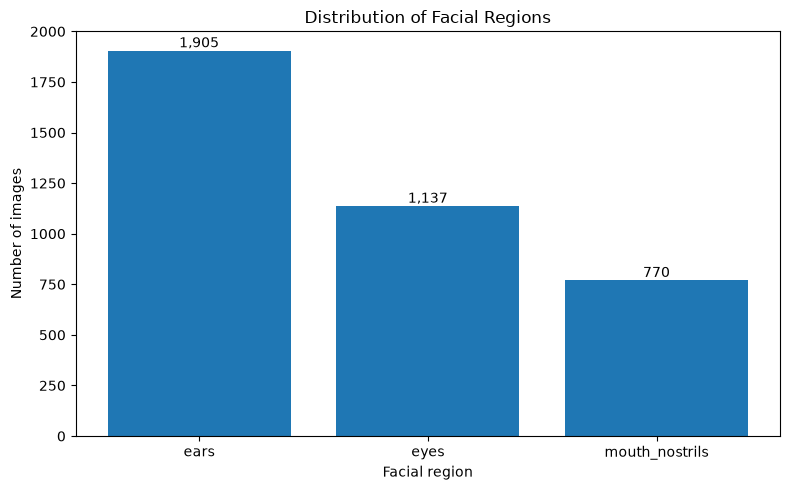

In [25]:
region_plot_data = (
    clean_df["face_region"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    region_plot_data.index,
    region_plot_data.values,
)

plt.title("Distribution of Facial Regions")
plt.xlabel("Facial region")
plt.ylabel("Number of images")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "face_region_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

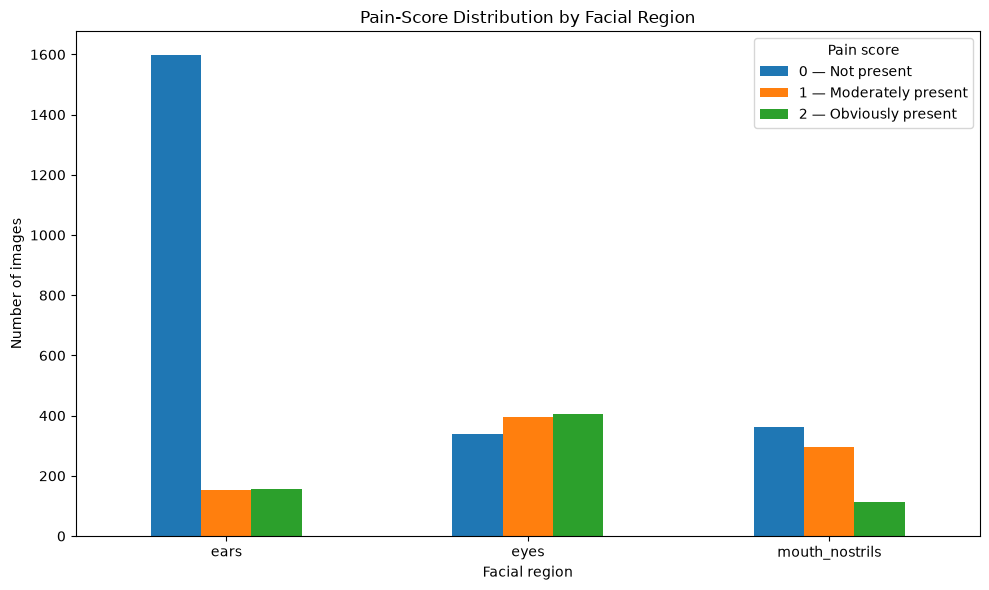

In [26]:
region_score_plot = pd.crosstab(
    clean_df["face_region"],
    clean_df["pain_score"],
)

region_score_plot.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Pain-Score Distribution by Facial Region")
plt.xlabel("Facial region")
plt.ylabel("Number of images")
plt.legend(
    title="Pain score",
    labels=[
        "0 — Not present",
        "1 — Moderately present",
        "2 — Obviously present",
    ],
)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pain_score_by_region.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

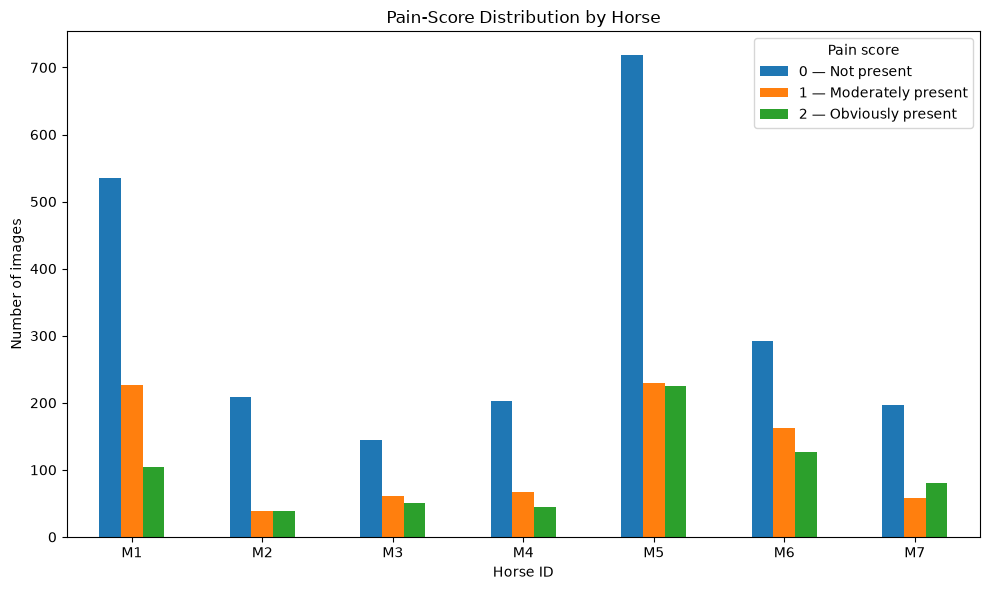

In [27]:
horse_score_plot = pd.crosstab(
    clean_df["horse_id"],
    clean_df["pain_score"],
)

horse_score_plot.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Pain-Score Distribution by Horse")
plt.xlabel("Horse ID")
plt.ylabel("Number of images")
plt.legend(
    title="Pain score",
    labels=[
        "0 — Not present",
        "1 — Moderately present",
        "2 — Obviously present",
    ],
)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pain_score_by_horse.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [28]:
horse_distribution = (
    clean_df["horse_id"]
    .value_counts()
    .sort_index()
)

horse_distribution

horse_id
M1     866
M2     285
M3     257
M4     315
M5    1173
M6     581
M7     335
Name: count, dtype: int64

Sample Images

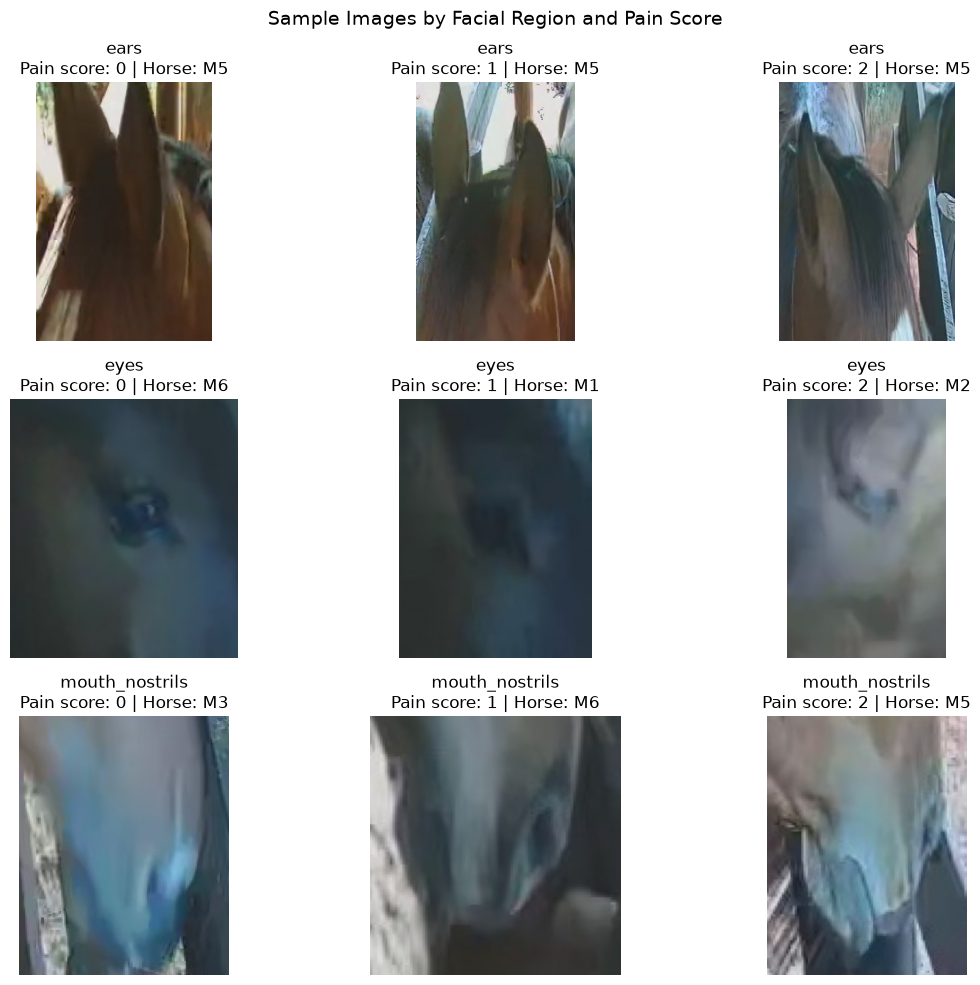

In [29]:
sample_rows = []

for face_region in sorted(
    clean_df["face_region"].unique()
):
    for pain_score in sorted(
        clean_df["pain_score"].unique()
    ):
        candidates = clean_df[
            (clean_df["face_region"] == face_region)
            & (clean_df["pain_score"] == pain_score)
        ]

        if not candidates.empty:
            sample_rows.append(
                candidates.sample(
                    n=1,
                    random_state=RANDOM_SEED,
                ).iloc[0]
            )

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 10),
)

for axis, row in zip(axes.flat, sample_rows):
    image_path = PROJECT_ROOT / row["image_path"]

    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))

    axis.set_title(
        f"{row['face_region']}\n"
        f"Pain score: {row['pain_score']} | "
        f"Horse: {row['horse_id']}"
    )

    axis.axis("off")

for axis in axes.flat[len(sample_rows):]:
    axis.axis("off")

plt.suptitle(
    "Sample Images by Facial Region and Pain Score",
    fontsize=14,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sample_images_by_region_and_score.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

train, validation, and test splits

In [30]:
official_horse_split = (
    clean_df
    .groupby("split_original")["horse_id"]
    .apply(lambda values: sorted(set(values)))
)

print(official_horse_split)

cross_split_horses = (
    set(
        clean_df.loc[
            clean_df["split_original"] == "train_raw",
            "horse_id",
        ]
    )
    & set(
        clean_df.loc[
            clean_df["split_original"] == "test_raw",
            "horse_id",
        ]
    )
)

print(
    "Horses appearing in both train_raw and test_raw:",
    cross_split_horses,
)

split_original
test_raw                 [M6, M7]
train_raw    [M1, M2, M3, M4, M5]
Name: horse_id, dtype: object
Horses appearing in both train_raw and test_raw: set()


In [42]:
VALIDATION_HORSE = "M4"

# Preserve the official dataset separation.
train_pool_df = clean_df[
    clean_df["split_original"] == "train_raw"
].copy()

test_df = clean_df[
    clean_df["split_original"] == "test_raw"
].copy()

# Use M4 exclusively for validation.
validation_df = train_pool_df[
    train_pool_df["horse_id"] == VALIDATION_HORSE
].copy()

# Train on the remaining official training horses.
train_df = train_pool_df[
    train_pool_df["horse_id"] != VALIDATION_HORSE
].copy()

train_df["split"] = "train"
validation_df["split"] = "validation"
test_df["split"] = "test"

train_df.reset_index(drop=True, inplace=True)
validation_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print(f"Training images:   {len(train_df):,}")
print(f"Validation images: {len(validation_df):,}")
print(f"Testing images:    {len(test_df):,}")

print("\nTraining horses:")
print(sorted(train_df["horse_id"].unique()))

print("\nValidation horses:")
print(sorted(validation_df["horse_id"].unique()))

print("\nTesting horses:")
print(sorted(test_df["horse_id"].unique()))

Training images:   2,581
Validation images: 315
Testing images:    916

Training horses:
['M1', 'M2', 'M3', 'M5']

Validation horses:
['M4']

Testing horses:
['M6', 'M7']


In [52]:
train_hashes = set(train_df["exported_sha256"])
validation_hashes = set(
    validation_df["exported_sha256"]
)
test_hashes = set(test_df["exported_sha256"])

train_validation_overlap = (
    train_hashes & validation_hashes
)

train_test_overlap = (
    train_hashes & test_hashes
)

validation_test_overlap = (
    validation_hashes & test_hashes
)

print(
    "Exact train-validation overlap:",
    len(train_validation_overlap),
)

print(
    "Exact train-test overlap:",
    len(train_test_overlap),
)

print(
    "Exact validation-test overlap:",
    len(validation_test_overlap),
)

assert len(train_validation_overlap) == 0
assert len(train_test_overlap) == 0
assert len(validation_test_overlap) == 0

Exact train-validation overlap: 0
Exact train-test overlap: 0
Exact validation-test overlap: 0


In [53]:
train_horses = set(train_df["horse_id"])
validation_horses = set(validation_df["horse_id"])
test_horses = set(test_df["horse_id"])

print("Train horses:", sorted(train_horses))
print("Validation horses:", sorted(validation_horses))
print("Test horses:", sorted(test_horses))

print(
    "Train-validation overlap:",
    train_horses & validation_horses,
)

print(
    "Train-test overlap:",
    train_horses & test_horses,
)

print(
    "Validation-test overlap:",
    validation_horses & test_horses,
)

assert not train_horses.intersection(validation_horses)
assert not train_horses.intersection(test_horses)
assert not validation_horses.intersection(test_horses)

print("\nNo horse identity leakage between splits.")

Train horses: ['M1', 'M2', 'M3', 'M5']
Validation horses: ['M4']
Test horses: ['M6', 'M7']
Train-validation overlap: set()
Train-test overlap: set()
Validation-test overlap: set()

No horse identity leakage between splits.


In [54]:
final_splits_df = pd.concat(
    [
        train_df,
        validation_df,
        test_df,
    ],
    ignore_index=True,
)

split_distribution = pd.crosstab(
    final_splits_df["split"],
    final_splits_df["pain_score"],
)

split_distribution

pain_score,0,1,2
split,,,
test,488,221,207
train,1607,555,419
validation,203,67,45


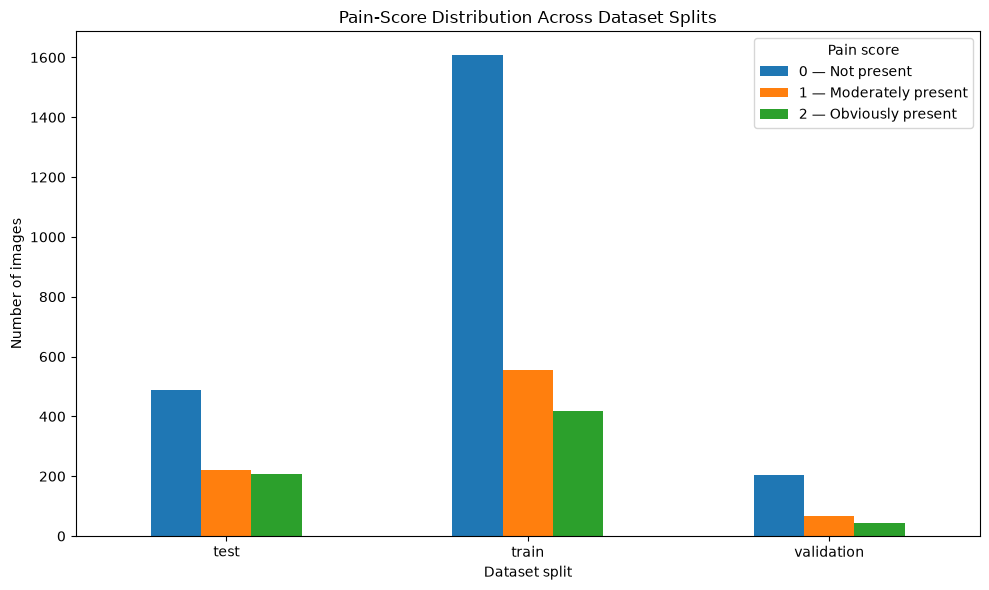

In [55]:
split_distribution.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Pain-Score Distribution Across Dataset Splits")
plt.xlabel("Dataset split")
plt.ylabel("Number of images")
plt.legend(
    title="Pain score",
    labels=[
        "0 — Not present",
        "1 — Moderately present",
        "2 — Obviously present",
    ],
)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "class_distribution_by_split.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [56]:
columns_to_save = [
    "image_path",
    "split",
    "horse_id",
    "face_region",
    "face_region_code",
    "pain_score",
    "pain_label",
    "binary_pain_label",
    "source_filename",
    "source_file_id",
    "source_sha256",
    "exported_sha256",
    "perceptual_hash",
    "width",
    "height",
    "mode",
]

train_df[columns_to_save].to_csv(
    SPLITS_DIR / "train.csv",
    index=False,
)

validation_df[columns_to_save].to_csv(
    SPLITS_DIR / "validation.csv",
    index=False,
)

test_df[columns_to_save].to_csv(
    SPLITS_DIR / "test.csv",
    index=False,
)

final_splits_df[columns_to_save].to_csv(
    SPLITS_DIR / "all_splits.csv",
    index=False,
)

print("Final split files saved:")
print(SPLITS_DIR / "train.csv")
print(SPLITS_DIR / "validation.csv")
print(SPLITS_DIR / "test.csv")

Final split files saved:
/home/uteam6/computer-vision-equine-grimace-scale/data/splits/train.csv
/home/uteam6/computer-vision-equine-grimace-scale/data/splits/validation.csv
/home/uteam6/computer-vision-equine-grimace-scale/data/splits/test.csv


In [61]:
def split_summary(dataframe, split_name):
    return {
        "split": split_name,
        "images": int(len(dataframe)),
        "horses": int(dataframe["horse_id"].nunique()),
        "horse_ids": sorted(
            dataframe["horse_id"].unique().tolist()
        ),
        "score_0": int(
            (dataframe["pain_score"] == 0).sum()
        ),
        "score_1": int(
            (dataframe["pain_score"] == 1).sum()
        ),
        "score_2": int(
            (dataframe["pain_score"] == 2).sum()
        ),
    }


final_summary = {
    "dataset": DATASET_NAME,
    "task": "three-class facial-region pain-score classification",
    "label_mapping": {
        "0": "not_present",
        "1": "moderately_present",
        "2": "obviously_present",
    },
    "initial_raw_records": int(
        len(dataset["train_raw"])
        + len(dataset["test_raw"])
    ),
    "corrupted_records": int(len(corrupted_df)),
    "exact_duplicates_removed": int(
        before_deduplication - after_deduplication
    ),
    "final_records": int(len(final_splits_df)),
    "splits": [
        split_summary(train_df, "train"),
        split_summary(validation_df, "validation"),
        split_summary(test_df, "test"),
    ],
}

with open(
    STATISTICS_DIR / "phase1_final_summary.json",
    "w",
) as file:
    json.dump(
        final_summary,
        file,
        indent=4,
    )

print(json.dumps(final_summary, indent=4))

{
    "dataset": "oliveirabruno01/openfarm-horse-grimace-region",
    "task": "three-class facial-region pain-score classification",
    "label_mapping": {
        "0": "not_present",
        "1": "moderately_present",
        "2": "obviously_present"
    },
    "initial_raw_records": 4847,
    "corrupted_records": 0,
    "exact_duplicates_removed": 1035,
    "final_records": 3812,
    "splits": [
        {
            "split": "train",
            "images": 2581,
            "horses": 4,
            "horse_ids": [
                "M1",
                "M2",
                "M3",
                "M5"
            ],
            "score_0": 1607,
            "score_1": 555,
            "score_2": 419
        },
        {
            "split": "validation",
            "images": 315,
            "horses": 1,
            "horse_ids": [
                "M4"
            ],
            "score_0": 203,
            "score_1": 67,
            "score_2": 45
        },
        {
            "split":

horse-aware validation split

In [58]:
candidate_summary = (
    train_pool_df
    .groupby(["horse_id", "face_region", "pain_score"])
    .size()
    .unstack(fill_value=0)
)

display(candidate_summary)

print("\nTotal images per candidate validation horse:")
print(
    train_pool_df["horse_id"]
    .value_counts()
    .sort_index()
)

pain_score                 0    1    2
horse_id face_region                  
M1       ears            284   43   25
         eyes            114   91   56
         mouth_nostrils  137   92   24
M2       ears            175    7   10
         eyes             26   22   28
         mouth_nostrils    8    9    0
M3       ears            104   13   17
         eyes             15   18   27
         mouth_nostrils   26   30    7
M4       ears            167    6    9
         eyes             18   40   27
         mouth_nostrils   18   21    9
M5       ears            522   39   32
         eyes             77  125  152
         mouth_nostrils  119   66   41


Total images per candidate validation horse:
horse_id
M1     866
M2     285
M3     257
M4     315
M5    1173
Name: count, dtype: int64


In [59]:
horse_class_summary = pd.crosstab(
    train_pool_df["horse_id"],
    train_pool_df["pain_score"],
)

display(horse_class_summary)

pain_score,0,1,2
horse_id,,,
M1,535,226,105
M2,209,38,38
M3,145,61,51
M4,203,67,45
M5,718,230,225


In [60]:
m4_region_summary = pd.crosstab(
    train_pool_df.loc[
        train_pool_df["horse_id"] == "M4",
        "face_region",
    ],
    train_pool_df.loc[
        train_pool_df["horse_id"] == "M4",
        "pain_score",
    ],
)

display(m4_region_summary)

pain_score,0,1,2
face_region,,,
ears,167,6,9
eyes,18,40,27
mouth_nostrils,18,21,9
